# Exercises

There are three exercises in this notebook:

1. Use the cross-validation method to test the linear regression with different $\alpha$ values, at least three.
2. Implement a SGD method that will train the Lasso regression for 10 epochs.
3. Extend the Fisher's classifier to work with two features. Use the class as the $y$.

## 1. Cross-validation linear regression

You need to change the variable ``alpha`` to be a list of alphas. Next do a loop and finally compare the results.

In [19]:
import numpy as np
import pandas as pd

x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)

x = np.asmatrix(np.c_[np.ones((15,1)),x])

I = np.identity(2)
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]  # change here

# add 1-3 line of code here
results = []
for alpha in alphas:
    w = np.linalg.inv(x.T * x + alpha * I) * x.T * y
    w = w.ravel()
    y_pred = x * w.T
    mse = np.mean(np.square(y - y_pred))
    results.append([alpha, float(w[0, 0]), float(w[0, 1]), float(mse)])

# add 1-3 lines to compare the results
results_df = pd.DataFrame(
    results, columns=["alpha", "bias", "weight", "mse"]
).sort_values("mse")
print(f"Best alpha: {results_df.iloc[0]['alpha']}")
results_df

Best alpha: 0.001


,alpha,bias,weight,mse
0,0.001,-179.526286,1.610230,372.348022
1,0.010,-167.855340,1.544160,373.793800
2,0.100,-101.723971,1.169788,426.045077
3,1.000,-20.590447,0.710486,592.463610
4,10.000,-2.291063,0.606881,645.579959
5,100.000,-0.228730,0.595091,651.926242


## 2. Implement based on the Ridge regression example, the Lasso regression.

Please implement the SGD method and compare the results with the sklearn Lasso regression results. 

In [20]:
def sgd():
    # your code goes here
    X = np.asarray(x, dtype=float)
    y_vec = np.asarray(y, dtype=float).reshape(-1, 1)

    n_samples, n_features = X.shape
    w = np.zeros((n_features, 1))

    lr = 1e-6
    epochs = 10
    lam = alpha

    for _ in range(epochs):
        indices = np.random.permutation(n_samples)
        for i in indices:
            xi = X[i:i + 1]
            yi = y_vec[i:i + 1]

            error = xi @ w - yi
            grad = 2.0 * xi.T @ error

            l1_subgrad = np.sign(w)
            l1_subgrad[0, 0] = 0.0

            w = w - lr * (grad + lam * l1_subgrad)

    return w

In [21]:
x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)

x = np.asmatrix(np.c_[np.ones((15,1)),x])

I = np.identity(2)
alpha = 0.1 


w = sgd() # update this line
w=w.ravel()

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

x_arr = np.asarray(x)
y_arr = np.asarray(y)

y_pred_sgd = x_arr @ w.reshape(-1, 1)
mse_sgd = mean_squared_error(y_arr, y_pred_sgd)

lasso = Lasso(alpha=alpha, fit_intercept=False, max_iter=100000, tol=1e-6)
lasso.fit(x_arr, y_arr.ravel())
y_pred_lasso = lasso.predict(x_arr).reshape(-1, 1)
mse_lasso = mean_squared_error(y_arr, y_pred_lasso)

comparison = pd.DataFrame([
    ["SGD Lasso", float(w[0]), float(w[1]), float(mse_sgd)],
    ["sklearn Lasso", float(lasso.coef_[0]), float(lasso.coef_[1]), float(mse_lasso)],
], columns=["model", "bias", "weight", "mse"])

comparison

,model,bias,weight,mse
0,SGD Lasso,0.002943,0.601802,654.571301
1,sklearn Lasso,-169.160481,1.551545,373.516272


## 3. Extend the Fisher's classifier

Please extend the targets of the ``iris_data`` variable and use it as the $y$.

Accuracy: 0.8333333333333334


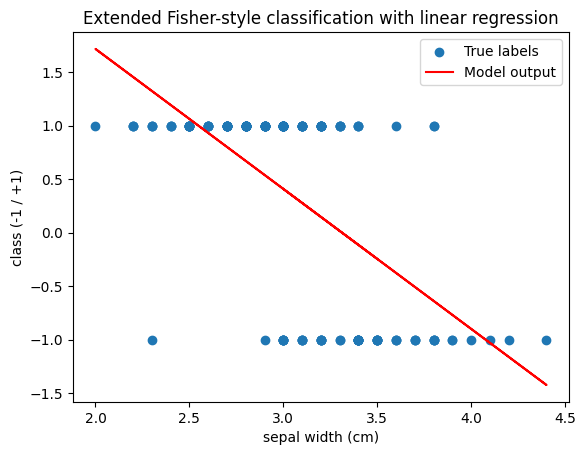

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris_data = load_iris()
iris_df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
iris_df.head()

x = iris_df["sepal width (cm)"].values  # change here
y = np.where(iris_data.target == 0, -1, 1)  # change here

dataset_size = np.size(x)

mean_x, mean_y = np.mean(x), np.mean(y)

SS_xy = np.sum(y * x) - dataset_size * mean_y * mean_x
SS_xx = np.sum(x * x) - dataset_size * mean_x * mean_x

a = SS_xy / SS_xx
b = mean_y - a * mean_x


y_pred = a * x + b

# checks
y_class = np.where(y_pred > 0, 1, -1)

accuracy = np.mean(y_class == y)
print("Accuracy:", accuracy)

# visualization
plt.scatter(x, y, label="True labels")
plt.plot(x, y_pred, color="red", label="Model output")
plt.xlabel("sepal width (cm)")
plt.ylabel("class (-1 / +1)")
plt.legend()
plt.title("Extended Fisher-style classification with linear regression")
plt.show()